# 02 plotting admixture results
Bur oak common garden genomics  
ahipp@mortonarb.org, 2024-09-20  

## Running this notebook
see `01.dataProcessingBash` for details. Make sure you run this notebook in the `garden` conda environment

## Making table of individuals and states
We need a table of individuals and states to do plot admixture results

In [1]:
datasets <- c('imputed', 'imputed.m90', 'raw.m90')
# datasets <- 'raw.m90'
dat <- read.csv('../out/oak.metadata.cleaned.csv', row.names = 1)
## write inds tables
for(i in datasets) {
    message(paste('making table for dataset', i))
    inds <- read.table(paste('../data/bed/KHU075_SNPcalls_20241105.', i, '.bp5000.fam', sep = ''))[[1]]
    spp <- dat[inds, 'Qsp']
    mother <- dat[inds, 'MOTHER']
    
    write.table(cbind(inds, spp, mother), 
                paste('../data/bed/inds.', i, '.bp5000.list', sep = ''),
                row.names = F, quote = F, col.names = F)
    } # close i
# head(dat)

making table for dataset imputed

making table for dataset imputed.m90

making table for dataset raw.m90



## Plot admixture results
I've been clunking along with long lines of code with this for awhile, so let's make a function:

In [2]:
library(pals) # because we'll need some extra colors

plotQ <- function(dat.Q, dat.inds, k, admixPath, fileBase, outPath, 
                  dropsies.spp = NA, dropsies.inds = NA, kLabel = NA,
                 writeQ = T) {
    
    if(k > 9) colSet <- cols25()[1:k]
    if(k <= 9) colSet <- palette.colors(k, palette = "Okabe-Ito") # works great up to 9
    if(is.na(kLabel)) kLabel <- k
    
    ## sort them
    sortOrder <- order(dat.inds$spp, dat.inds$inds)
    dat.inds <- dat.inds[sortOrder,]
    dat.Q <- dat.Q[sortOrder, ]
    
    ## prune them
    if(!is.na(dropsies.spp[1])) {
        dat.Q <- dat.Q[!dat.inds$spp %in% dropsies.spp, ]
        dat.inds <- dat.inds[!dat.inds$spp %in% dropsies.spp, ]
    }
    if(!is.na(dropsies.inds[1])) {
        dat.Q <- dat.Q[!dat.inds$inds %in% dropsies.inds, ]
        dat.inds <- dat.inds[!dat.inds$inds %in% dropsies.inds, ]
    }
    
    pdf(paste(outPath, dataset, '/k', kLabel, '.', fileBase, '.pdf', sep = ''), 20, 6)
    par(mar = c(8, 4, 4, 2) + 0.1)
    labs <- table(dat.inds$spp)
    temp <- t(dat.Q)
    colnames(temp) <- as.numeric(1:dim(temp)[2])
    barLocs <- barplot(temp, 
            border = NA, 
            xaxt = 'n', 
            yaxt = 'n',
            xpd = F,
            col = colSet,
            main = paste('MOR ACE experiment, K =', kLabel))
    abline(v = barLocs[cumsum(labs)], col = 'black', lwd = 2)
    axis(1, at = barLocs[as.integer(cumsum(labs) - c(19, diff(cumsum(labs))/2))], 
            labels = names(labs), 
            tick = F, 
            las = 3, 
            cex.lab = 0.5
            )
    dev.off()
    if(writeQ) {
        # head(dat.inds$inds)
        row.names(dat.Q) <- dat.inds$inds
        write.csv(dat.Q, paste(outPath, dataset, '/k', kLabel, '.', fileBase, '.Q', sep = ''))
        }
} # close function

And now let's actually run it:

In [3]:
for(dataset in datasets) {
    message(paste('plotting dataset', dataset))
    tableName <- paste('../data/bed/inds.', dataset, '.bp5000.list', sep = '')
    admixPath <- paste('../out/admixture/', dataset, '/', sep = '')
    fileBase <- paste('KHU075_SNPcalls_20241105.', dataset, '.bp5000', sep = '')
    for(k in 2:10) {
        dat.inds <- read.table(tableName)
        names(dat.inds) <- c('inds', 'spp')
        dat.Q <- try(read.table(paste(admixPath, fileBase, '.', k, '.Q', sep = '')))
        if(class(dat.Q) == 'try-error') next
        plotQ(dat.Q = dat.Q, dat.inds = dat.inds, admixPath = admixPath, fileBase = fileBase, k = k, outPath = '../out/admixture.plots/')
    } # close k
} # close dataset

plotting dataset imputed

plotting dataset imputed.m90

plotting dataset raw.m90



## Consolidate to species
Now we'll clean up admixture results to species, aiming to see which _Q. macrocarpa_ in the garden are admixed, This bascially does the above plotting but consolidates _Q. macrocarpa_ columns. First, I want to look at the data and decide how I'm going to select columns that are not _Q. macrocarpa_ specific.... Okay, I did that and consolidated it into this function. You can break out the pieces if you like to see how it works.

In [4]:
macQ <- function(indsMat = dat.inds, Qmat = dat.Q, todo = c('mac', 'NS')) {
    spp <- unique(indsMat$spp)
    spp.noMac <- grep('macrocarpa', spp, invert = T, value = T)
    spp.sums <- sapply(spp, function(x) apply(Qmat[which(indsMat$spp == x), ], 2, mean)) |> t()    
    # spp.sums <- rbind(spp.sums, macSum = apply(spp.sums[grep('macrocarpa', row.names(spp.sums)), ], 2, sum))
    max.col <- colnames(spp.sums)[sapply(spp, function(x) which(spp.sums[x, ] == max(spp.sums[x, ])))]
    names(max.col) <- spp
    # just differentiate macrocarpa
    if(todo[1] == 'mac') {
        macro.cols <- setdiff(colnames(Qmat), max.col[spp.noMac])
        new.Qmat <- cbind(Qmat[, setdiff(colnames(Qmat), macro.cols), drop = F], 
                      macSum = apply(Qmat[, macro.cols, drop = F], 1, sum)
                     )
        }
    # differentiate macN and macS
    if(todo[1] == 'NS') {
        #### LEFT OFF HERE ####
        }
    attr(new.Qmat, 'macro.cols') <- macro.cols
    attr(new.Qmat, "maxCols") <- max.col
    attr(new.Qmat, "sppSums") <- spp.sums |> round(3)
    attr(new.Qmat, 'k') <- dim(new.Qmat)[2]
    attr(new.Qmat, 'kLabel') <- paste(dim(Qmat)[2], "_viz_", dim(new.Qmat)[2], sep = '')
    return(new.Qmat)
    }

# now try it
message('ORIGINAL Q MATRIX:')
dat.Q |> head()
out <- macQ()
message('Q MATRIX AFTER MACROCARPAS ARE SUMMED:')
out |> head()
attr(out, 'sppSums')
attr(out, 'maxCols')
message('New k:')
attr(out, 'k')
message('k-label:')
attr(out, 'kLabel')

ORIGINAL Q MATRIX:



,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000495,0.000010,0.024047,0.00001,0.966682,0.000010,0.000010,0.007693,0.000010,0.001033
2,0.000010,0.000010,0.000010,0.00001,0.000010,0.000010,0.000010,0.000010,0.000010,0.999910
3,0.020987,0.009971,0.236079,0.00610,0.287222,0.067591,0.091488,0.257424,0.004783,0.018355
4,0.000010,0.000010,0.000010,0.00001,0.000010,0.000010,0.000010,0.000010,0.000010,0.999910
5,0.000010,0.000010,0.000010,0.00001,0.000010,0.000010,0.000010,0.000018,0.000010,0.999902
6,0.000010,0.000010,0.000010,0.00001,0.000010,0.000010,0.000010,0.000010,0.000010,0.999910


Q MATRIX AFTER MACROCARPAS ARE SUMMED:



,V2,V5,V8,V9,V10,macSum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000010,0.966682,0.007693,0.000010,0.001033,0.024572
2,0.000010,0.000010,0.000010,0.000010,0.999910,0.000050
3,0.009971,0.287222,0.257424,0.004783,0.018355,0.422245
4,0.000010,0.000010,0.000010,0.000010,0.999910,0.000050
5,0.000010,0.000010,0.000018,0.000010,0.999902,0.000050
6,0.000010,0.000010,0.000010,0.000010,0.999910,0.000050


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
muehlenbergii,0.002,0.000,0.007,0.000,0.970,0.003,0.005,0.008,0.001,0.004
stellata,0.000,0.001,0.000,0.000,0.000,0.000,0.001,0.037,0.000,0.961
macrocarpa,0.464,0.006,0.118,0.059,0.005,0.070,0.254,0.004,0.016,0.004
alba,0.004,0.000,0.006,0.003,0.001,0.003,0.027,0.954,0.002,0.000
macrocarpa_IL,0.110,0.003,0.123,0.051,0.002,0.170,0.536,0.004,0.002,0.001
macrocarpa_MN,0.015,0.002,0.124,0.107,0.002,0.052,0.693,0.001,0.002,0.002
macrocarpa_OK,0.758,0.001,0.070,0.017,0.014,0.013,0.103,0.001,0.018,0.004
michauxii,0.035,0.057,0.001,0.000,0.010,0.002,0.001,0.845,0.024,0.024
lyrata,0.031,0.909,0.003,0.000,0.000,0.000,0.000,0.000,0.057,0.000
bicolor,0.066,0.005,0.010,0.003,0.042,0.006,0.011,0.015,0.842,0.000


muehlenbergii      stellata    macrocarpa          alba macrocarpa_IL 
         "V5"         "V10"          "V1"          "V8"          "V7" 
macrocarpa_MN macrocarpa_OK     michauxii        lyrata       bicolor 
         "V7"          "V1"          "V8"          "V2"          "V9" 
      montana       sinuata 
         "V8"         "V10"

New k:



[1] 6

k-label:



[1] "10_viz_6"

and now let's do it:

In [5]:
for(dataset in datasets) {
    message(paste('plotting consolidated', dataset))
    tableName <- paste('../data/bed/inds.', dataset, '.bp5000.list', sep = '')
    admixPath <- paste('../out/admixture/', dataset, '/', sep = '')
    fileBase <- paste('KHU075_SNPcalls_20241105.', dataset, '.bp5000', sep = '')
    outPath <- '../out/admixture.plots.consolidated/'
    kSet <- 2:10 # seems to separate Q. mac at K > 5 and higher
    dat.inds <- read.table(tableName)
    names(dat.inds) <- c('inds', 'spp')
    for(k in kSet) {
        dat.Q <- read.table(paste(admixPath, fileBase, '.', k, '.Q', sep = '')) |> try()
        if(class(dat.Q) == 'try-error') next
        dat.Q.consolidated <- macQ(dat.inds, dat.Q)
        plotQ(dat.Q = dat.Q.consolidated, dat.inds = dat.inds, 
              admixPath = admixPath, fileBase = fileBase, 
              k = attr(dat.Q.consolidated, 'k'), kLabel = attr(dat.Q.consolidated, 'kLabel'), 
              outPath = outPath)
    } # close k
} # close dataset


plotting consolidated imputed

plotting consolidated imputed.m90

plotting consolidated raw.m90



And now, let's compare introgression between the raw and imputed datasets. First, we'll choose the best CV for each:

pdf 
  2

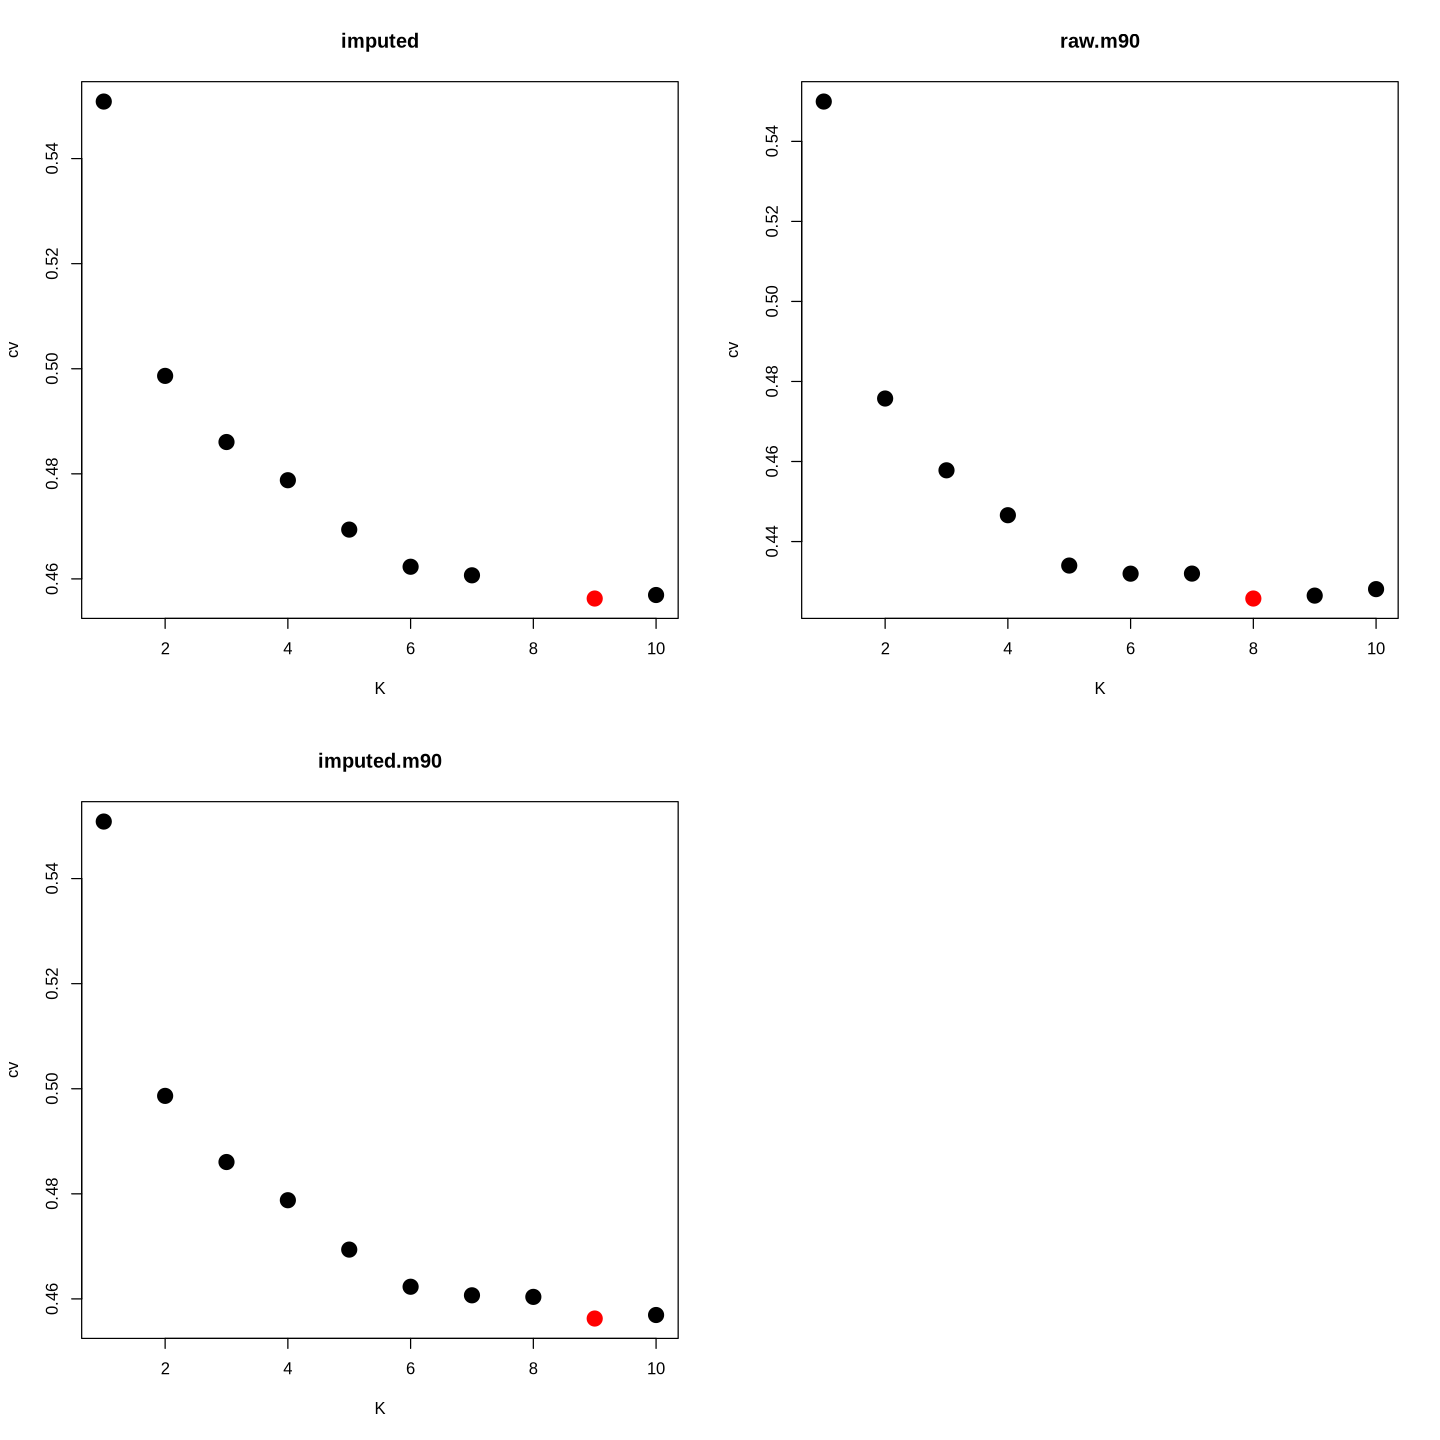

In [6]:
options(repr.plot.width = 12, repr.plot.height = 12)
cv <- lapply(setNames(datasets, datasets), function(x) read.table(paste('../out/admixture/', x, '/', x, '.cv.txt', sep = '')))
cv <- lapply(cv, function(x) structure(x, names = c('K', 'cv')))

layout(matrix(1:4, 2))
for(i in names(cv)) {
    cv[[i]]$K <- gsub(pattern = '[(K=):]', replacement = '', cv[[i]]$K) |> as.integer()
    cv[[i]] <- cv[[i]][order(cv[[i]]$K), ]
    row.names(cv[[i]]) <- NULL
    temp.col <- rep('black', dim(cv[[i]])[1])
    temp.col[which(cv[[i]]$cv == min(cv[[i]]$cv))] <- 'red'
    plot(cv[[i]], pch = 19, cex = 2, main = i, col = temp.col)
    } # close i

pdf('../out/FIG-Sx.Kplots.pdf')
layout(matrix(1:4, 2))
for(i in names(cv)) {
    cv[[i]]$K <- gsub(pattern = '[(K=):]', replacement = '', cv[[i]]$K) |> as.integer()
    cv[[i]] <- cv[[i]][order(cv[[i]]$K), ]
    row.names(cv[[i]]) <- NULL
    temp.col <- rep('black', dim(cv[[i]])[1])
    temp.col[which(cv[[i]]$cv == min(cv[[i]]$cv))] <- 'red'
    plot(cv[[i]], pch = 19, cex = 2, main = i, col = temp.col)
    } # close i
dev.off()

And now let's read in the `min(cv)` Q table for the raw.m90 and the imputed.m90 table, match 'em up, and then regress the max Qs.

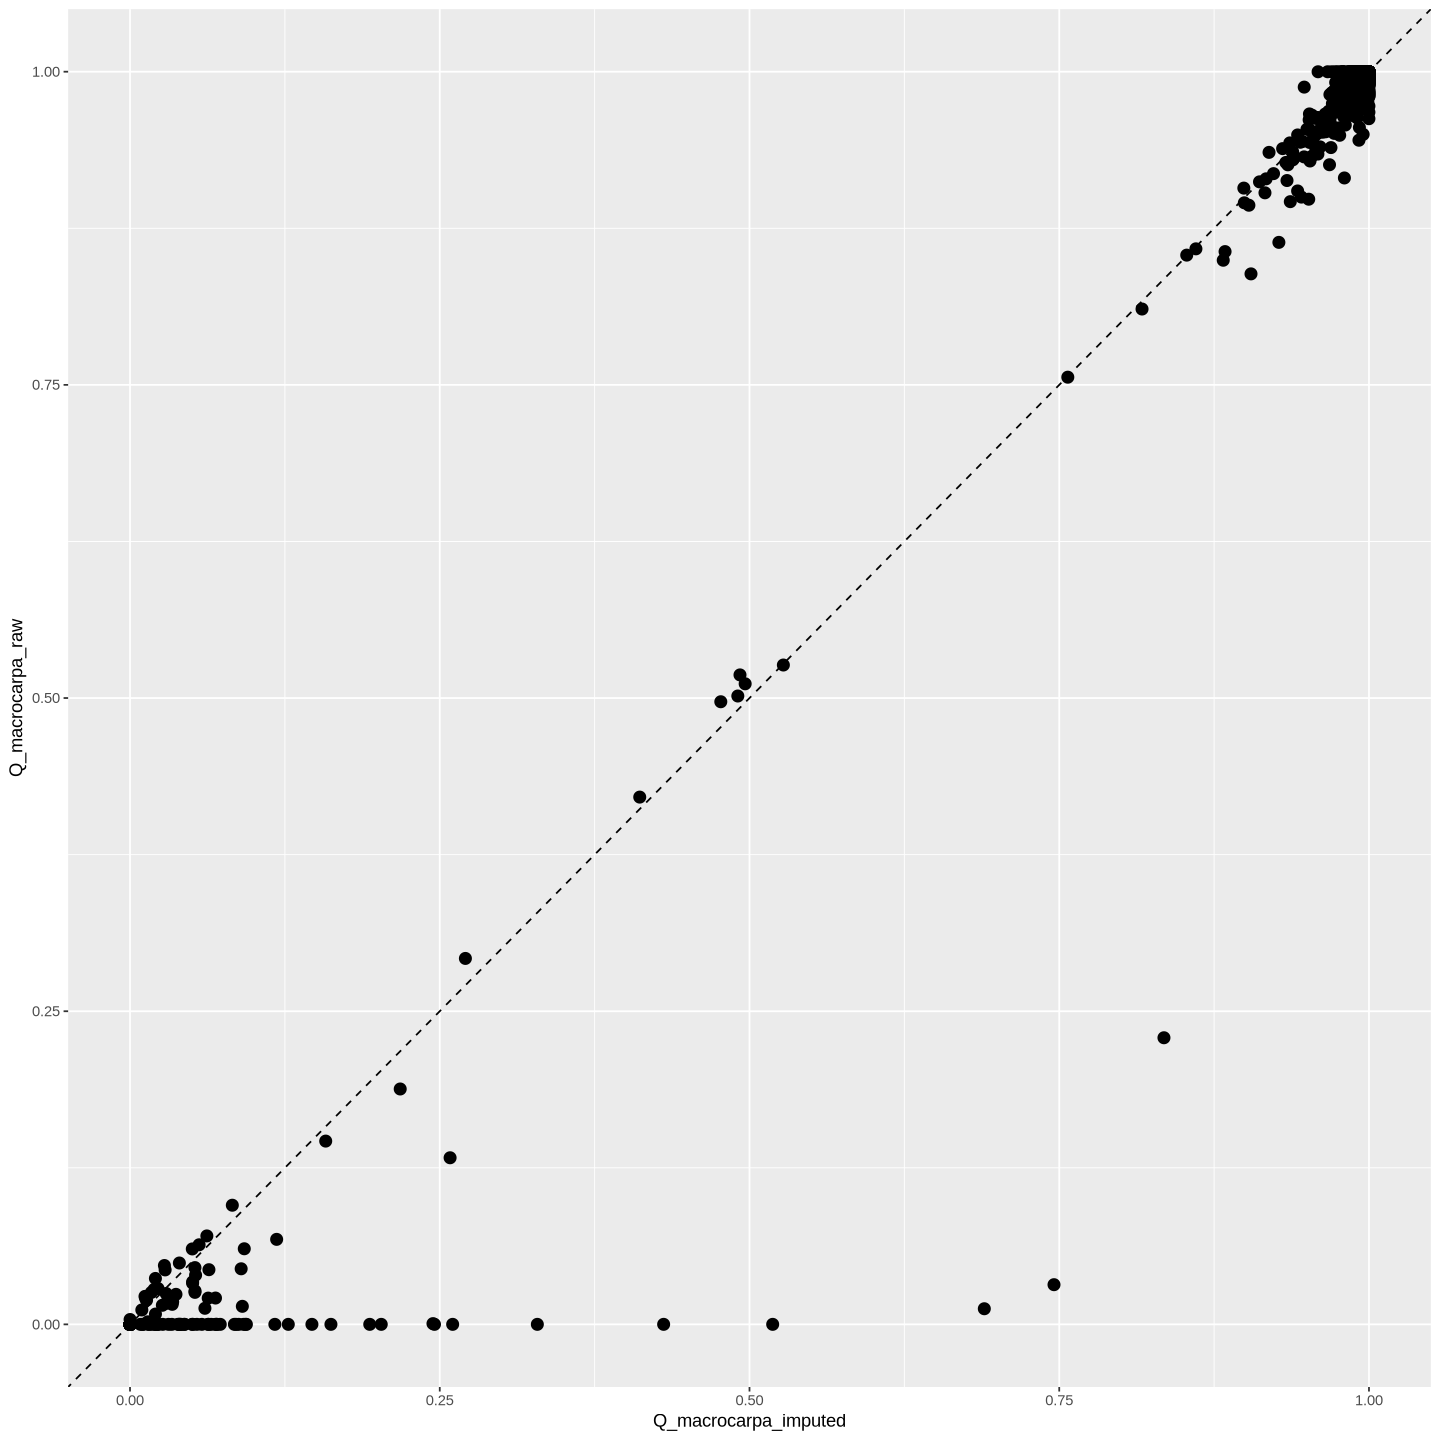

In [7]:
library(ggplot2)
dat.Q.consolidated <- lapply(c(imputed.m90 = 'imputed.m90', raw.m90 = 'raw.m90'), function(dataset) {
    tableName <- paste('../data/bed/inds.', dataset, '.bp5000.list', sep = '')
    admixPath <- paste('../out/admixture/', dataset, '/', sep = '')
    fileBase <- paste('KHU075_SNPcalls_20241105.', dataset, '.bp5000', sep = '')
    
    dat.inds <- read.table(tableName)
    names(dat.inds) <- c('inds', 'spp')
    
    dat.Q <- read.table(paste(admixPath, fileBase, '.', ifelse(dataset == 'imputed.m90', 9, 8), '.Q', sep = ''))
    out <- macQ(dat.inds, dat.Q)
    row.names(out) <- dat.inds$inds
    return(out)
    } # close dat.Q
) # close lapply
whichdo <- intersect(row.names(dat.Q.consolidated[[1]]), row.names(dat.Q.consolidated[[2]]))

dat.Q.macSums <- data.frame(
    Q_macrocarpa_imputed = dat.Q.consolidated$imputed.m90[whichdo, 'macSum'],
    Q_macrocarpa_raw = dat.Q.consolidated$raw.m90[whichdo, 'macSum'],
    row.names = whichdo
    )

p <- ggplot(dat.Q.macSums, aes(x = Q_macrocarpa_imputed, y = Q_macrocarpa_raw))
p <- p + geom_point(size = 3)
# p <- p + geom_jitter()
# p <- p + geom_smooth(method = 'lm')
# p <- p + theme_bw()
p <- p + geom_abline(slope = 1, intercept = 0, lty = 'dashed')
print(p)

This shows that the imputed data systematically estimated higher levels of introgression in non-macrocarpa individuals. Biased upward? or is introgression as estimated from the raw data biased downward? We'll need to compare with the genomic data to know.